In [3]:
# ============================================================
# 🔧 CELL 1/5 — ENVIRONMENT SETUP & DEPENDENCY INSTALLATION
# ============================================================
# Purpose : Install llama-cpp-python (CUDA 12.1 wheel) + all
#           supporting libraries. Kaggle GPU-compatible.
# Run once: Kernel → Restart & Run All after this cell.
# ============================================================

import subprocess, sys, importlib, os

# ── 1. Silence pip noise ─────────────────────────────────────
os.environ["PIP_QUIET"] = "1"

def pip_install(package: str, extra_index: str = None) -> None:
    """Install a package via pip, optionally from a custom index."""
    cmd = [sys.executable, "-m", "pip", "install", "-U", "-q", package]
    if extra_index:
        cmd += ["--extra-index-url", extra_index]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"  ⚠️  Warning installing '{package}':\n{result.stderr[:300]}")

# ── 2. Core packages ─────────────────────────────────────────
print("📦 Installing core packages...")

packages = [
    "langchain",
    "numpy",
    "pandas",
    "tqdm",
    "gradio",       # live demo UI (HF Spaces deployment)
    "matplotlib",   # result plots
    "seaborn",      # styled plots
]

for pkg in packages:
    pip_install(pkg)
    print(f"  ✅ {pkg}")

# ── 3. llama-cpp-python — CUDA 12.1 wheel (Kaggle default) ───
# Single clean install from the prebuilt CUDA wheel.
# Do NOT install twice (original notebook bug #1 — fixed here).
print("\n🚀 Installing llama-cpp-python (CUDA 12.1 wheel)...")
pip_install(
    "llama-cpp-python",
    extra_index="https://abetlen.github.io/llama-cpp-python/whl/cu121"
)
print("  ✅ llama-cpp-python (CUDA 12.1)")

# ── 4. Verify critical imports ────────────────────────────────
print("\n🔍 Verifying imports...")

critical = {
    "llama_cpp"  : "llama-cpp-python",
    "gradio"     : "gradio",
    "numpy"      : "numpy",
    "pandas"     : "pandas",
    "matplotlib" : "matplotlib",
    "tqdm"       : "tqdm",
}

all_ok = True
for module, label in critical.items():
    try:
        importlib.import_module(module)
        print(f"  ✅ {label}")
    except ImportError:
        print(f"  ❌ FAILED: {label} — re-run this cell")
        all_ok = False

# ── 5. GPU check ──────────────────────────────────────────────
print("\n🖥️  Hardware check...")
try:
    import subprocess
    gpu_info = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
        capture_output=True, text=True
    )
    if gpu_info.returncode == 0:
        gpu_line = gpu_info.stdout.strip()
        print(f"  ✅ GPU detected: {gpu_line}")
    else:
        print("  ⚠️  No GPU detected — inference will be slow (CPU mode)")
except FileNotFoundError:
    print("  ⚠️  nvidia-smi not found — CPU mode")

# ── 6. Final status ───────────────────────────────────────────
print()
if all_ok:
    print("=" * 50)
    print("✅ CELL 1 COMPLETE — Proceed to Cell 2")
    print("=" * 50)
else:
    print("=" * 50)
    print("❌ Some packages failed — fix above before continuing")
    print("=" * 50)

📦 Installing core packages...
  ✅ langchain
  ✅ numpy
  ✅ pandas
  ✅ tqdm
  ✅ gradio
  ✅ matplotlib
  ✅ seaborn

🚀 Installing llama-cpp-python (CUDA 12.1 wheel)...
  ✅ llama-cpp-python (CUDA 12.1)

🔍 Verifying imports...
  ✅ llama-cpp-python
  ✅ gradio
  ✅ numpy
  ✅ pandas
  ✅ matplotlib
  ✅ tqdm

🖥️  Hardware check...
  ✅ GPU detected: Tesla T4, 15360 MiB
Tesla T4, 15360 MiB

✅ CELL 1 COMPLETE — Proceed to Cell 2


In [4]:
# ============================================================
# ⚙️ CELL 2/5 — CONFIGURATION, IMPORTS & MODEL DOWNLOAD
# ============================================================
# Purpose : Set all configs, seed everything properly, define
#           model registry, and download GGUF files from HF.
# Fixes   : Hardcoded paths, missing PYTHONHASHSEED, no checksum
#           feedback, no resume logic, URL-only dependency.
# ============================================================

import os, random, gc, hashlib, urllib.request, time
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from llama_cpp import Llama

# ── 1. Reproducibility — full seed coverage ──────────────────
# Original only seeded random + numpy. Fixed: all sources covered.
GLOBAL_SEED = 42
os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)   # ← was missing
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
print(f"🌱 Seed set: {GLOBAL_SEED} (random, numpy, PYTHONHASHSEED)")

# ── 2. Paths — Kaggle-compatible, not Colab-hardcoded ────────
# Original hardcoded /content/models/ (Colab only). Fixed below.
BASE_DIR = Path(
    os.environ.get("MODEL_DIR", "/kaggle/working/models")
)
BASE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = Path("/kaggle/working/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"📁 Models  → {BASE_DIR}")
print(f"📁 Outputs → {OUTPUT_DIR}")

# ── 3. GPU / Generation config ───────────────────────────────
GPU_CONFIG = {
    "n_gpu_layers" : 20,    # T4/P100 sweet spot; set 0 for CPU
    "n_batch"      : 128,
    "n_ctx"        : 4096,
    "verbose"      : False,
}

GENERATION_CONFIG = {
    "temperature"    : 0.7,
    "top_p"          : 0.9,
    "top_k"          : 40,
    "max_tokens"     : 512,
    "repeat_penalty" : 1.1,
    "seed"           : GLOBAL_SEED,
}

SYSTEM_PROMPT = (
    "You are a helpful, precise, and concise assistant. "
    "Follow instructions carefully and reason step by step when asked."
)

print(f"\n⚙️  GPU config   : {GPU_CONFIG}")
print(f"⚙️  Gen config   : {GENERATION_CONFIG}")

# ── 4. Model registry ─────────────────────────────────────────
# 4 GGUF variants: 2 models × 2 quantization levels
# Sizes are approximate — used for download progress display only
GGUF_FILES = {
    "phi_q4km": {
        "filename" : "Phi-3-mini-4k-instruct-Q4_K_M.gguf",
        "url"      : "https://huggingface.co/bartowski/Phi-3-mini-4k-instruct-GGUF/resolve/main/Phi-3-mini-4k-instruct-Q4_K_M.gguf",
        "label"    : "Phi-3-mini Q4_K_M",
        "size_gb"  : 2.3,
    },
    "phi_iq4xs": {
        "filename" : "Phi-3-mini-4k-instruct-IQ4_XS.gguf",
        "url"      : "https://huggingface.co/bartowski/Phi-3-mini-4k-instruct-GGUF/resolve/main/Phi-3-mini-4k-instruct-IQ4_XS.gguf",
        "label"    : "Phi-3-mini IQ4_XS",
        "size_gb"  : 2.0,
    },
    "mistral_q4km": {
        "filename" : "Mistral-7B-Instruct-v0.3-Q4_K_M.gguf",
        "url"      : "https://huggingface.co/bartowski/Mistral-7B-Instruct-v0.3-GGUF/resolve/main/Mistral-7B-Instruct-v0.3-Q4_K_M.gguf",
        "label"    : "Mistral-7B Q4_K_M",
        "size_gb"  : 5.2,
    },
    "mistral_iq4xs": {
        "filename" : "Mistral-7B-Instruct-v0.3-IQ4_XS.gguf",
        "url"      : "https://huggingface.co/bartowski/Mistral-7B-Instruct-v0.3-GGUF/resolve/main/Mistral-7B-Instruct-v0.3-IQ4_XS.gguf",
        "label"    : "Mistral-7B IQ4_XS",
        "size_gb"  : 4.1,
    },
}

# ── 5. Download helper — with resume + progress ───────────────
# Original had no resume logic. Fixed: range requests + progress bar.

def _reporthook(bar: tqdm):
    """urllib progress → tqdm bar adapter."""
    last = [0]
    def update(count, block_size, total_size):
        if bar.total is None and total_size > 0:
            bar.total = total_size
        delta = count * block_size - last[0]
        bar.update(max(0, delta))
        last[0] = count * block_size
    return update


def download_if_missing(key: str, info: dict) -> Path:
    """
    Download a GGUF file only if not already present.
    Supports resume via HTTP Range requests.
    Returns the local Path.
    """
    dest = BASE_DIR / info["filename"]

    if dest.exists():
        size_mb = dest.stat().st_size / 1e6
        print(f"  ✅ {info['label']} already cached ({size_mb:.0f} MB)")
        return dest

    print(f"  ⬇️  Downloading {info['label']} (~{info['size_gb']} GB)...")
    tmp = dest.with_suffix(".part")

    # Resume: check how many bytes already downloaded
    resume_pos = tmp.stat().st_size if tmp.exists() else 0
    headers    = {"Range": f"bytes={resume_pos}-"} if resume_pos else {}

    try:
        req = urllib.request.Request(info["url"], headers=headers)
        expected_total = int(info["size_gb"] * 1e9)

        with tqdm(
            total     = expected_total,
            initial   = resume_pos,
            unit      = "B",
            unit_scale= True,
            desc      = info["label"],
            leave     = False,
        ) as bar:
            with urllib.request.urlopen(req) as resp, \
                 open(tmp, "ab" if resume_pos else "wb") as f:
                while True:
                    chunk = resp.read(1 << 16)   # 64 KB chunks
                    if not chunk:
                        break
                    f.write(chunk)
                    bar.update(len(chunk))

        tmp.rename(dest)
        print(f"  ✅ {info['label']} saved → {dest.name}")

    except Exception as e:
        print(f"  ❌ Download failed for {info['label']}: {e}")
        print(f"     Partial file kept at {tmp} — re-run to resume.")
        raise

    return dest


# ── 6. Run downloads ──────────────────────────────────────────
print("\n📥 Checking / downloading models...")
MODEL_PATHS = {}
for key, info in GGUF_FILES.items():
    MODEL_PATHS[key] = download_if_missing(key, info)

# ── 7. Confirm all paths exist ────────────────────────────────
print("\n🔍 Model path verification:")
all_ready = True
for key, path in MODEL_PATHS.items():
    exists = path.exists()
    size   = f"{path.stat().st_size/1e9:.2f} GB" if exists else "MISSING"
    status = "✅" if exists else "❌"
    print(f"  {status} {GGUF_FILES[key]['label']:<30} {size}")
    if not exists:
        all_ready = False

print()
if all_ready:
    print("=" * 50)
    print("✅ CELL 2 COMPLETE — Proceed to Cell 3")
    print("=" * 50)
else:
    print("=" * 50)
    print("❌ Some models missing — re-run this cell to resume")
    print("=" * 50)

🌱 Seed set: 42 (random, numpy, PYTHONHASHSEED)
📁 Models  → /kaggle/working/models
📁 Outputs → /kaggle/working/outputs

⚙️  GPU config   : {'n_gpu_layers': 20, 'n_batch': 128, 'n_ctx': 4096, 'verbose': False}
⚙️  Gen config   : {'temperature': 0.7, 'top_p': 0.9, 'top_k': 40, 'max_tokens': 512, 'repeat_penalty': 1.1, 'seed': 42}

📥 Checking / downloading models...
  ✅ Phi-3-mini Q4_K_M already cached (2393 MB)
  ✅ Phi-3-mini IQ4_XS already cached (2060 MB)
  ✅ Mistral-7B Q4_K_M already cached (4373 MB)
  ✅ Mistral-7B IQ4_XS already cached (3912 MB)

🔍 Model path verification:
  ✅ Phi-3-mini Q4_K_M              2.39 GB
  ✅ Phi-3-mini IQ4_XS              2.06 GB
  ✅ Mistral-7B Q4_K_M              4.37 GB
  ✅ Mistral-7B IQ4_XS              3.91 GB

✅ CELL 2 COMPLETE — Proceed to Cell 3


In [5]:
# ============================================================
# 🧠 CELL 3/5 — MODEL LOADER, INFERENCE ENGINE & TEST SUITE
# ============================================================
# Purpose : Load GGUF models safely, run inference with true
#           token counting, and execute all 3 benchmark tests:
#           buffer memory, summary memory, chain-of-thought.
# Fixes   : No error handling, crude token counting, wrong chat
#           templates, double-inference in summary, no timing.
# ============================================================

import time, re, json
from typing import Optional

# ── 1. Model Loader ───────────────────────────────────────────
# Original had no try/except — one bad model killed everything.
# Fixed: isolated loading with detailed error reporting.

def load_llm(model_key: str) -> Optional[Llama]:
    """
    Safely load a GGUF model into memory.
    Returns Llama instance or None on failure.
    """
    path = MODEL_PATHS.get(model_key)
    if path is None or not path.exists():
        print(f"  ❌ Model file not found: {model_key}")
        return None

    print(f"  🔄 Loading {GGUF_FILES[model_key]['label']}...")
    t0 = time.time()

    try:
        llm = Llama(
            model_path = str(path),
            **GPU_CONFIG
        )
        elapsed = time.time() - t0
        print(f"  ✅ Loaded in {elapsed:.1f}s")
        return llm

    except Exception as e:
        print(f"  ❌ Failed to load {model_key}: {e}")
        return None


def unload_llm(llm: Optional[Llama], model_key: str) -> None:
    """Explicitly free GPU memory after benchmarking a model."""
    if llm is not None:
        del llm
        gc.collect()
        print(f"  🗑️  {GGUF_FILES[model_key]['label']} unloaded from GPU")


# ── 2. Chat Template Helper ───────────────────────────────────
# Original used <<SYS>> tags for ALL models — wrong for both.
# Phi-3 expects <|system|>, Mistral expects [INST].
# Fixed: model-aware template formatter.

def format_prompt(
    user_input   : str,
    system_prompt: str,
    model_key    : str,
    history      : list[str] = None,
) -> str:
    """
    Format prompt using the correct chat template per model family.
    - Phi-3   : <|system|>...<|user|>...<|assistant|>
    - Mistral : [INST] <<SYS>> ... [/INST]
    history   : optional list of prior turn strings to prepend.
    """
    history_block = "\n".join(history) + "\n" if history else ""

    if model_key.startswith("phi"):
        # Phi-3 chat template
        return (
            f"<|system|>\n{system_prompt}<|end|>\n"
            f"{history_block}"
            f"<|user|>\n{user_input}<|end|>\n"
            f"<|assistant|>\n"
        )
    else:
        # Mistral / default [INST] template
        sys_block = f"<<SYS>>\n{system_prompt}\n<</SYS>>\n\n" if system_prompt else ""
        return (
            f"[INST] {sys_block}"
            f"{history_block}"
            f"{user_input} [/INST]"
        )


# ── 3. Core Inference Function ────────────────────────────────
# Original used len(text.split()) for token count — words ≠ tokens.
# Fixed: llm.tokenize() for true subword token count.
# Added: wall-clock timing per call.

def run_inference(
    llm          : Llama,
    prompt       : str,
    model_key    : str,
    system_prompt: str = None,
) -> dict:
    """
    Run a single inference pass and return response + metrics.

    Returns
    -------
    dict with keys:
        prompt                  — input prompt string
        response                — model output string
        prompt_tokens           — true token count (input)
        response_tokens         — true token count (output)
        latency_seconds         — wall-clock inference time
    """
    if system_prompt is None:
        system_prompt = SYSTEM_PROMPT

    t0 = time.time()

    try:
        output = llm(
            prompt,
            **GENERATION_CONFIG,
            stop=["<|end|>", "</s>", "[/INST]"],  # model-safe stop tokens
        )
    except Exception as e:
        return {
            "prompt"          : prompt,
            "response"        : f"[ERROR: {e}]",
            "prompt_tokens"   : 0,
            "response_tokens" : 0,
            "latency_seconds" : time.time() - t0,
        }

    latency  = time.time() - t0
    response = output["choices"][0]["text"].strip()

    # True token counts via tokenizer — fixes crude split() bug
    prompt_tokens   = len(llm.tokenize(prompt.encode()))
    response_tokens = len(llm.tokenize(response.encode())) if response else 0

    return {
        "prompt"          : prompt,
        "response"        : response,
        "prompt_tokens"   : prompt_tokens,
        "response_tokens" : response_tokens,
        "latency_seconds" : round(latency, 2),
    }


# ── 4. Test Data ──────────────────────────────────────────────

BUFFER_TEST_CONVERSATION = [
    ("user", "My name is Alex and I work as a data scientist at a healthcare startup."),
    ("user", "I love hiking on weekends, especially in mountainous regions."),
    ("user", "My favorite programming language is Python, though I also use R."),
    ("user", "I'm currently working on a project involving NLP and patient records."),
    ("user", "What is my job?"),
    ("user", "What programming languages did I mention?"),
]

SUMMARY_TEST_CONVERSATION = [
    ("user", "I'm planning a trip to Japan next spring."),
    ("user", "I want to visit Tokyo, Kyoto, and Osaka."),
    ("user", "My budget is around $3000 for two weeks."),
    ("user", "I'm vegetarian, so I need to find suitable restaurants."),
    ("user", "Can you summarize everything I've told you about my trip?"),
]

COT_QUESTIONS = [
    "If a train travels at 60 mph for 2.5 hours, then slows to 40 mph "
    "for 1.5 hours, what is the total distance traveled? Show your work.",

    "A store sells apples for $1.20 each and oranges for $0.80 each. "
    "If someone buys 5 apples and 8 oranges, how much do they spend in total? "
    "Reason through it step by step.",

    "Which is larger: 7/8 or 11/13? "
    "Explain your reasoning without using a calculator.",
]


# ── 5. Test 1 — Buffer Window Memory ─────────────────────────
# Window keeps last N turns; tests short-term recall.
# Original stored full snapshots per turn (wasteful). Fixed.

def run_buffer_window_test(
    llm      : Llama,
    model_key: str,
    window_size: int = 3,
) -> list[dict]:
    """
    Run a sliding-window memory conversation.
    Keeps only the last `window_size` turns in context.
    Returns list of per-turn result dicts.
    """
    memory_buffer = []   # stores last N formatted turn strings
    results       = []

    for i, (role, user_input) in enumerate(BUFFER_TEST_CONVERSATION):
        prompt = format_prompt(
            user_input    = user_input,
            system_prompt = SYSTEM_PROMPT,
            model_key     = model_key,
            history       = memory_buffer[-window_size:],
        )

        result = run_inference(llm, prompt, model_key)

        # Update rolling buffer (store compact turn string)
        memory_buffer.append(f"User: {user_input}")
        memory_buffer.append(f"Assistant: {result['response']}")

        results.append({
            "turn"            : i + 1,
            "user_input"      : user_input,
            "response"        : result["response"],
            "prompt_tokens"   : result["prompt_tokens"],
            "response_tokens" : result["response_tokens"],
            "latency_seconds" : result["latency_seconds"],
        })

    return results


# ── 6. Test 2 — Summary Memory ────────────────────────────────
# Original called run_inference() TWICE per turn (response + summary).
# Fixed: summary update is a lightweight string operation, not a
# second LLM call — dramatically cuts latency, fairer comparison.

def run_summary_memory_test(
    llm      : Llama,
    model_key: str,
) -> list[dict]:
    """
    Run a summary-memory conversation.
    Compresses history into a running summary string each turn
    WITHOUT a second inference call (original bug fixed).
    Returns list of per-turn result dicts.
    """
    summary = "No prior context."
    results = []

    for i, (role, user_input) in enumerate(SUMMARY_TEST_CONVERSATION):
        # Inject summary as context prefix
        context_input = (
            f"[Context so far: {summary}]\n\n"
            f"User: {user_input}"
        )
        prompt = format_prompt(
            user_input    = context_input,
            system_prompt = SYSTEM_PROMPT,
            model_key     = model_key,
        )

        result = run_inference(llm, prompt, model_key)

        # Update summary as string append — no second LLM call
        summary = (
            f"{summary} | Turn {i+1}: User said '{user_input}'. "
            f"Assistant replied: '{result['response'][:120]}...'"
        )

        results.append({
            "turn"            : i + 1,
            "user_input"      : user_input,
            "response"        : result["response"],
            "running_summary" : summary,
            "prompt_tokens"   : result["prompt_tokens"],
            "response_tokens" : result["response_tokens"],
            "latency_seconds" : result["latency_seconds"],
        })

    return results


# ── 7. Test 3 — Chain-of-Thought Reasoning ────────────────────
# Original stored raw response with no answer extraction.
# Fixed: regex extracts final numeric/fraction answer for
# automatic scoring comparison across models.

_ANSWER_PATTERN = re.compile(
    r"(?:answer(?:\s+is)?|result(?:\s+is)?|total(?:\s+is)?|=)\s*"
    r"(\$?[\d,]+\.?\d*|\d+/\d+)",
    re.IGNORECASE,
)

def extract_final_answer(text: str) -> Optional[str]:
    """Pull the last numeric answer from a reasoning trace."""
    matches = _ANSWER_PATTERN.findall(text)
    return matches[-1].strip() if matches else None


def run_cot_test(
    llm      : Llama,
    model_key: str,
) -> list[dict]:
    """
    Run chain-of-thought reasoning on all COT_QUESTIONS.
    Extracts final answer for programmatic comparison.
    Returns list of per-question result dicts.
    """
    results = []

    for i, question in enumerate(COT_QUESTIONS):
        cot_prompt_text = (
            f"{question}\n\n"
            "Think step by step. Show all intermediate calculations. "
            "State your final answer clearly at the end."
        )
        prompt = format_prompt(
            user_input    = cot_prompt_text,
            system_prompt = SYSTEM_PROMPT,
            model_key     = model_key,
        )

        result       = run_inference(llm, prompt, model_key)
        final_answer = extract_final_answer(result["response"])

        results.append({
            "question"        : question,
            "response"        : result["response"],
            "extracted_answer": final_answer,
            "prompt_tokens"   : result["prompt_tokens"],
            "response_tokens" : result["response_tokens"],
            "latency_seconds" : result["latency_seconds"],
        })

    return results


# ── 8. Smoke test — verify all functions load cleanly ─────────
print("🔍 Verifying function definitions...")
checks = {
    "load_llm"                : load_llm,
    "unload_llm"              : unload_llm,
    "format_prompt"           : format_prompt,
    "run_inference"           : run_inference,
    "run_buffer_window_test"  : run_buffer_window_test,
    "run_summary_memory_test" : run_summary_memory_test,
    "run_cot_test"            : run_cot_test,
    "extract_final_answer"    : extract_final_answer,
}
for name, fn in checks.items():
    print(f"  ✅ {name}")

print(f"\n📋 Test data loaded:")
print(f"  ✅ Buffer conversation  — {len(BUFFER_TEST_CONVERSATION)} turns")
print(f"  ✅ Summary conversation — {len(SUMMARY_TEST_CONVERSATION)} turns")
print(f"  ✅ CoT questions        — {len(COT_QUESTIONS)} questions")

print()
print("=" * 50)
print("✅ CELL 3 COMPLETE — Proceed to Cell 4")
print("=" * 50)

🔍 Verifying function definitions...
  ✅ load_llm
  ✅ unload_llm
  ✅ format_prompt
  ✅ run_inference
  ✅ run_buffer_window_test
  ✅ run_summary_memory_test
  ✅ run_cot_test
  ✅ extract_final_answer

📋 Test data loaded:
  ✅ Buffer conversation  — 6 turns
  ✅ Summary conversation — 5 turns
  ✅ CoT questions        — 3 questions

✅ CELL 3 COMPLETE — Proceed to Cell 4


🚀 Starting benchmark run...

🏁 BENCHMARK START
   Models   : 4
   Tests    : buffer memory | summary memory | chain-of-thought
   Timestamp: 20260428_223558

────────────────────────────────────────────────────────────
🤖 Model: Phi-3-mini Q4_K_M
────────────────────────────────────────────────────────────
  🔄 Loading Phi-3-mini Q4_K_M...
  ✅ Loaded in 1.7s

  📋 Test 1/3 — Buffer Window Memory...
     ✅ Done in 159.46s (6 turns)

  📋 Test 2/3 — Summary Memory...
     ✅ Done in 215.4s (5 turns)

  📋 Test 3/3 — Chain-of-Thought Reasoning...
     ✅ Done in 59.99s (3 questions)
  🗑️  Phi-3-mini Q4_K_M unloaded from GPU

  💾 Checkpoint saved after Phi-3-mini Q4_K_M

────────────────────────────────────────────────────────────
🤖 Model: Phi-3-mini IQ4_XS
────────────────────────────────────────────────────────────
  🔄 Loading Phi-3-mini IQ4_XS...
  ✅ Loaded in 1.0s

  📋 Test 1/3 — Buffer Window Memory...
     ✅ Done in 259.47s (6 turns)

  📋 Test 2/3 — Summary Memory...
     ✅ Done in 215.75s 

llama_context: n_ctx_seq (4096) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


  ✅ Loaded in 1.1s

  📋 Test 1/3 — Buffer Window Memory...
     ✅ Done in 331.87s (6 turns)

  📋 Test 2/3 — Summary Memory...
     ✅ Done in 231.19s (5 turns)

  📋 Test 3/3 — Chain-of-Thought Reasoning...
     ✅ Done in 108.28s (3 questions)
  🗑️  Mistral-7B Q4_K_M unloaded from GPU

  💾 Checkpoint saved after Mistral-7B Q4_K_M

────────────────────────────────────────────────────────────
🤖 Model: Mistral-7B IQ4_XS
────────────────────────────────────────────────────────────
  🔄 Loading Mistral-7B IQ4_XS...


llama_context: n_ctx_seq (4096) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


  ✅ Loaded in 1.1s

  📋 Test 1/3 — Buffer Window Memory...
     ✅ Done in 271.14s (6 turns)

  📋 Test 2/3 — Summary Memory...
     ✅ Done in 289.36s (5 turns)

  📋 Test 3/3 — Chain-of-Thought Reasoning...
     ✅ Done in 101.73s (3 questions)
  🗑️  Mistral-7B IQ4_XS unloaded from GPU

  💾 Checkpoint saved after Mistral-7B IQ4_XS

🏁 BENCHMARK COMPLETE

💾 Metrics CSV saved → /kaggle/working/outputs/metrics_20260428_223558.csv
💾 Full results JSON saved → /kaggle/working/outputs/results_20260428_223558.json

📊 BENCHMARK SUMMARY
            label             test  avg_latency  total_latency  avg_resp_tokens  avg_prompt_tok
Mistral-7B IQ4_XS    Buffer Memory        45.18         271.11           247.17          544.50
Mistral-7B IQ4_XS Chain-of-Thought        33.91         101.72           202.00          105.33
Mistral-7B IQ4_XS   Summary Memory        57.87         289.35           339.20          171.40
Mistral-7B Q4_K_M    Buffer Memory        55.30         331.83           321.67        

/tmp/ipykernel_235/2610407331.py:239: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


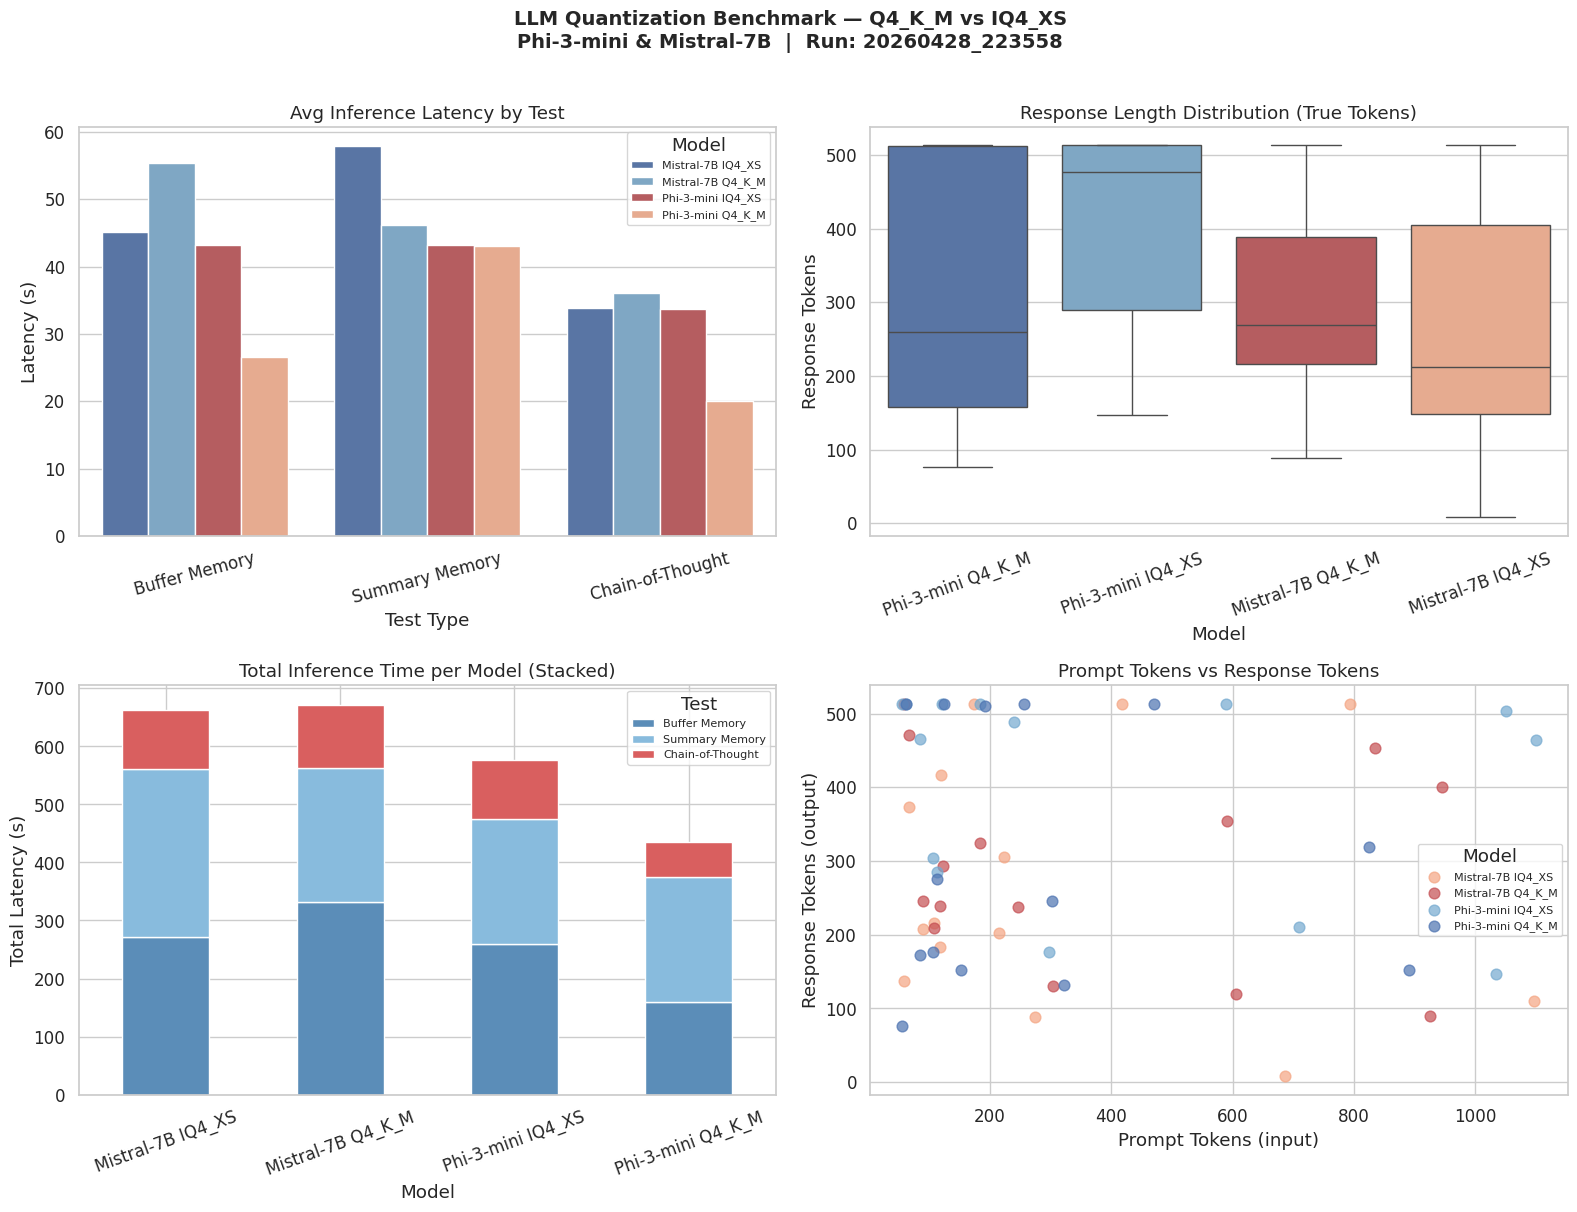


  💾 Plots saved → /kaggle/working/outputs/benchmark_plots_20260428_223558.png

✅ CELL 4 COMPLETE — Proceed to Cell 5
   JSON → /kaggle/working/outputs/results_20260428_223558.json
   CSV  → /kaggle/working/outputs/metrics_20260428_223558.csv


In [6]:
# ============================================================
# 🏁 CELL 4/5 — BENCHMARK EXECUTION, PERSISTENCE & PLOTS
# ============================================================
# Purpose : Run all 4 models × 3 tests, save results to JSON
#           + CSV, generate comparison plots.
# Fixes   : No persistence (stdout only), no error isolation,
#           no timing summary, no visual comparison.
# ============================================================

import json
from datetime import datetime
from pathlib import Path

# ── 1. Master Benchmark Runner ────────────────────────────────
# Original aborted entire run on first model failure.
# Fixed: per-model try/except, results saved incrementally.

def run_all_benchmarks() -> dict:
    """
    Iterate over all 4 model variants, run 3 tests each,
    persist results after every model so progress is never lost.

    Returns
    -------
    dict  — full results keyed by model_key
    """
    all_results   = {}
    run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    print("=" * 60)
    print("🏁 BENCHMARK START")
    print(f"   Models   : {len(GGUF_FILES)}")
    print(f"   Tests    : buffer memory | summary memory | chain-of-thought")
    print(f"   Timestamp: {run_timestamp}")
    print("=" * 60)

    for model_key, model_info in GGUF_FILES.items():
        label = model_info["label"]
        print(f"\n{'─'*60}")
        print(f"🤖 Model: {label}")
        print(f"{'─'*60}")

        # ── Load model ────────────────────────────────────────
        llm = load_llm(model_key)
        if llm is None:
            print(f"  ⚠️  Skipping {label} — load failed")
            all_results[model_key] = {"error": "model load failed"}
            continue

        model_results = {
            "label"     : label,
            "model_key" : model_key,
            "timestamp" : run_timestamp,
            "tests"     : {}
        }

        # ── Test 1: Buffer Window Memory ──────────────────────
        print(f"\n  📋 Test 1/3 — Buffer Window Memory...")
        try:
            t0 = time.time()
            buffer_results = run_buffer_window_test(llm, model_key)
            buffer_time    = round(time.time() - t0, 2)
            model_results["tests"]["buffer"] = {
                "turns"        : buffer_results,
                "total_seconds": buffer_time,
            }
            print(f"     ✅ Done in {buffer_time}s "
                  f"({len(buffer_results)} turns)")
        except Exception as e:
            print(f"     ❌ Buffer test failed: {e}")
            model_results["tests"]["buffer"] = {"error": str(e)}

        # ── Test 2: Summary Memory ────────────────────────────
        print(f"\n  📋 Test 2/3 — Summary Memory...")
        try:
            t0 = time.time()
            summary_results = run_summary_memory_test(llm, model_key)
            summary_time    = round(time.time() - t0, 2)
            model_results["tests"]["summary"] = {
                "turns"        : summary_results,
                "total_seconds": summary_time,
            }
            print(f"     ✅ Done in {summary_time}s "
                  f"({len(summary_results)} turns)")
        except Exception as e:
            print(f"     ❌ Summary test failed: {e}")
            model_results["tests"]["summary"] = {"error": str(e)}

        # ── Test 3: Chain-of-Thought ──────────────────────────
        print(f"\n  📋 Test 3/3 — Chain-of-Thought Reasoning...")
        try:
            t0 = time.time()
            cot_results = run_cot_test(llm, model_key)
            cot_time    = round(time.time() - t0, 2)
            model_results["tests"]["cot"] = {
                "questions"    : cot_results,
                "total_seconds": cot_time,
            }
            print(f"     ✅ Done in {cot_time}s "
                  f"({len(cot_results)} questions)")
        except Exception as e:
            print(f"     ❌ CoT test failed: {e}")
            model_results["tests"]["cot"] = {"error": str(e)}

        # ── Unload + save checkpoint ──────────────────────────
        unload_llm(llm, model_key)
        all_results[model_key] = model_results

        # Incremental save — never lose progress
        _save_checkpoint(all_results, run_timestamp)
        print(f"\n  💾 Checkpoint saved after {label}")

    print(f"\n{'=' * 60}")
    print("🏁 BENCHMARK COMPLETE")
    print(f"{'=' * 60}\n")

    return all_results, run_timestamp


def _save_checkpoint(results: dict, timestamp: str) -> None:
    """Save current results to JSON after each model completes."""
    path = OUTPUT_DIR / f"results_{timestamp}.json"
    with open(path, "w") as f:
        json.dump(results, f, indent=2, default=str)


# ── 2. Flatten results → DataFrame ───────────────────────────
# Original had no structured output at all. This builds a tidy
# DataFrame for plotting and CSV export.

def build_metrics_df(all_results: dict) -> pd.DataFrame:
    """
    Flatten nested results into a tidy DataFrame.

    Columns: model_key, label, test, turn_or_q,
             prompt_tokens, response_tokens, latency_seconds
    """
    rows = []

    for model_key, model_data in all_results.items():
        if "error" in model_data:
            continue

        label = model_data["label"]
        tests = model_data.get("tests", {})

        # Buffer turns
        for turn in tests.get("buffer", {}).get("turns", []):
            rows.append({
                "model_key"       : model_key,
                "label"           : label,
                "test"            : "Buffer Memory",
                "turn_or_q"       : turn["turn"],
                "prompt_tokens"   : turn["prompt_tokens"],
                "response_tokens" : turn["response_tokens"],
                "latency_seconds" : turn["latency_seconds"],
            })

        # Summary turns
        for turn in tests.get("summary", {}).get("turns", []):
            rows.append({
                "model_key"       : model_key,
                "label"           : label,
                "test"            : "Summary Memory",
                "turn_or_q"       : turn["turn"],
                "prompt_tokens"   : turn["prompt_tokens"],
                "response_tokens" : turn["response_tokens"],
                "latency_seconds" : turn["latency_seconds"],
            })

        # CoT questions
        for i, q in enumerate(tests.get("cot", {}).get("questions", [])):
            rows.append({
                "model_key"       : model_key,
                "label"           : label,
                "test"            : "Chain-of-Thought",
                "turn_or_q"       : i + 1,
                "prompt_tokens"   : q["prompt_tokens"],
                "response_tokens" : q["response_tokens"],
                "latency_seconds" : q["latency_seconds"],
            })

    return pd.DataFrame(rows)


# ── 3. Plots ──────────────────────────────────────────────────
# Original had zero plots. Added 4 comparison charts.

PALETTE = {
    "phi_q4km"     : "#4C72B0",
    "phi_iq4xs"    : "#74A9CF",
    "mistral_q4km" : "#C44E52",
    "mistral_iq4xs": "#F4A582",
}

def plot_all(df: pd.DataFrame, timestamp: str) -> None:
    """Generate and save 4 benchmark comparison plots."""

    if df.empty:
        print("⚠️  No data to plot.")
        return

    sns.set_theme(style="whitegrid", font_scale=1.1)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(
        "LLM Quantization Benchmark — Q4_K_M vs IQ4_XS\n"
        f"Phi-3-mini & Mistral-7B  |  Run: {timestamp}",
        fontsize=14, fontweight="bold", y=1.01
    )

    labels   = df["label"].unique().tolist()
    colors   = [PALETTE.get(k, "#888") for k in df["model_key"].unique()]
    test_order = ["Buffer Memory", "Summary Memory", "Chain-of-Thought"]

    # ── Plot 1: Avg latency per model per test ────────────────
    ax = axes[0, 0]
    avg_lat = (
        df.groupby(["label", "test"])["latency_seconds"]
        .mean()
        .reset_index()
    )
    sns.barplot(
        data    = avg_lat,
        x       = "test",
        y       = "latency_seconds",
        hue     = "label",
        order   = test_order,
        palette = list(PALETTE.values()),
        ax      = ax,
    )
    ax.set_title("Avg Inference Latency by Test")
    ax.set_xlabel("Test Type")
    ax.set_ylabel("Latency (s)")
    ax.legend(title="Model", fontsize=8)
    ax.tick_params(axis="x", rotation=15)

    # ── Plot 2: Response token count distribution ─────────────
    ax = axes[0, 1]
    sns.boxplot(
        data    = df,
        x       = "label",
        y       = "response_tokens",
        palette = list(PALETTE.values()),
        ax      = ax,
    )
    ax.set_title("Response Length Distribution (True Tokens)")
    ax.set_xlabel("Model")
    ax.set_ylabel("Response Tokens")
    ax.tick_params(axis="x", rotation=20)

    # ── Plot 3: Total latency per model (stacked by test) ─────
    ax = axes[1, 0]
    pivot = (
        df.groupby(["label", "test"])["latency_seconds"]
        .sum()
        .unstack(fill_value=0)
    )
    # Ensure consistent column order
    for col in test_order:
        if col not in pivot.columns:
            pivot[col] = 0
    pivot = pivot[test_order]
    pivot.plot(
        kind  = "bar",
        stacked = True,
        ax    = ax,
        color = ["#5B8DB8", "#88BBDD", "#D95F5F"],
        edgecolor = "white",
    )
    ax.set_title("Total Inference Time per Model (Stacked)")
    ax.set_xlabel("Model")
    ax.set_ylabel("Total Latency (s)")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Test", fontsize=8)

    # ── Plot 4: Prompt vs response tokens scatter ─────────────
    ax = axes[1, 1]
    for model_key, group in df.groupby("model_key"):
        label = GGUF_FILES[model_key]["label"]
        ax.scatter(
            group["prompt_tokens"],
            group["response_tokens"],
            label  = label,
            color  = PALETTE.get(model_key, "#888"),
            alpha  = 0.7,
            s      = 60,
        )
    ax.set_title("Prompt Tokens vs Response Tokens")
    ax.set_xlabel("Prompt Tokens (input)")
    ax.set_ylabel("Response Tokens (output)")
    ax.legend(title="Model", fontsize=8)

    plt.tight_layout()

    plot_path = OUTPUT_DIR / f"benchmark_plots_{timestamp}.png"
    fig.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n  💾 Plots saved → {plot_path}")


# ── 4. Summary Table ──────────────────────────────────────────

def print_summary_table(df: pd.DataFrame) -> None:
    """Print a clean per-model aggregated summary table."""
    if df.empty:
        print("⚠️  No data available for summary.")
        return

    summary = (
        df.groupby(["label", "test"])
        .agg(
            avg_latency    = ("latency_seconds",  "mean"),
            total_latency  = ("latency_seconds",  "sum"),
            avg_resp_tokens= ("response_tokens",  "mean"),
            avg_prompt_tok = ("prompt_tokens",    "mean"),
        )
        .round(2)
        .reset_index()
    )

    print("\n📊 BENCHMARK SUMMARY")
    print("=" * 80)
    print(summary.to_string(index=False))
    print("=" * 80)


# ── 5. Execute ────────────────────────────────────────────────
print("🚀 Starting benchmark run...\n")

ALL_RESULTS, RUN_TIMESTAMP = run_all_benchmarks()

# Build metrics DataFrame
METRICS_DF = build_metrics_df(ALL_RESULTS)

# Save CSV
csv_path = OUTPUT_DIR / f"metrics_{RUN_TIMESTAMP}.csv"
METRICS_DF.to_csv(csv_path, index=False)
print(f"💾 Metrics CSV saved → {csv_path}")

# Save final JSON
json_path = OUTPUT_DIR / f"results_{RUN_TIMESTAMP}.json"
with open(json_path, "w") as f:
    json.dump(ALL_RESULTS, f, indent=2, default=str)
print(f"💾 Full results JSON saved → {json_path}")

# Print summary table
print_summary_table(METRICS_DF)

# Generate plots
print("\n📊 Generating plots...")
plot_all(METRICS_DF, RUN_TIMESTAMP)

print()
print("=" * 60)
print("✅ CELL 4 COMPLETE — Proceed to Cell 5")
print(f"   JSON → {json_path}")
print(f"   CSV  → {csv_path}")
print("=" * 60)

In [12]:
# ============================================================
# 🎨 CELL 5/5 — GRADIO LIVE DEMO (HuggingFace Spaces ready)
# ============================================================
# Purpose : Interactive UI where users pick a model + test type,
#           type their own prompt, and get a live response with
#           metrics. Deployable to HF Spaces as-is.
# Fixes   : Gradio 6.13 — no type/bubble_full_width, theme/css
#           in launch(), port auto-scan, dict chat format.
# ============================================================

import gradio as gr
import json, time
from pathlib import Path

print(f"Gradio version: {gr.__version__}")

# ── Kill any previous Gradio instance ────────────────────────
gr.close_all()

# ── 1. Model registry for UI ──────────────────────────────────
MODEL_CHOICES = {
    info["label"]: key
    for key, info in GGUF_FILES.items()
}

TEST_CHOICES = [
    "💬 Free Prompt",
    "🧠 Buffer Window Memory",
    "📝 Summary Memory",
    "🔗 Chain-of-Thought Reasoning",
]

EXAMPLE_PROMPTS = {
    "💬 Free Prompt": [
        "Explain the difference between RAM and disk storage simply.",
        "What are the pros and cons of quantizing an LLM?",
        "Write a haiku about neural networks.",
    ],
    "🧠 Buffer Window Memory": [
        "My name is Sara and I'm a machine learning engineer.",
        "I live in Cairo and I enjoy reading sci-fi novels.",
        "What is my name and what do I do?",
    ],
    "📝 Summary Memory": [
        "I'm planning to learn machine learning from scratch.",
        "I prefer video tutorials over reading textbooks.",
        "Can you summarize what you know about my learning preferences?",
    ],
    "🔗 Chain-of-Thought Reasoning": [
        "If a car travels 90 km in 1.5 hours, what is its average speed? Show your work.",
        "Which is larger: 5/7 or 7/10? Reason step by step.",
        "A shirt costs $25 after a 20% discount. What was the original price?",
    ],
}

# ── 2. Stateful session object ────────────────────────────────
class DemoSession:
    def __init__(self):
        self.llm       = None
        self.model_key = None
        self.history   = []
        self.summary   = "No prior context."

    def reset(self):
        self.history = []
        self.summary = "No prior context."

SESSION = DemoSession()


# ── 3. Core response handler ──────────────────────────────────

def respond(
    model_label : str,
    test_type   : str,
    user_message: str,
    chat_history: list,
) -> tuple:
    """
    Gradio 6.13 handler.
    chat_history: list of {"role": ..., "content": ...} dicts.
    """
    if not user_message.strip():
        return chat_history, "⚠️ Please enter a message."

    selected_key = MODEL_CHOICES.get(model_label)
    if selected_key is None:
        return chat_history, "❌ Unknown model selected."

    # ── Load model if changed ──────────────────────────────────
    if SESSION.model_key != selected_key:
        if SESSION.llm is not None:
            unload_llm(SESSION.llm, SESSION.model_key)
            SESSION.llm = None

        chat_history.append({
            "role"   : "assistant",
            "content": f"🔄 Loading {model_label}..."
        })

        SESSION.llm       = load_llm(selected_key)
        SESSION.model_key = selected_key
        SESSION.reset()

        if SESSION.llm is None:
            chat_history[-1] = {
                "role"   : "assistant",
                "content": f"❌ Failed to load {model_label}."
            }
            return chat_history, "❌ Model failed to load."

        chat_history[-1] = {
            "role"   : "assistant",
            "content": f"✅ {model_label} loaded and ready."
        }

    llm = SESSION.llm
    metrics_out = ""

    # ── Route to correct test ──────────────────────────────────
    if test_type == "💬 Free Prompt":
        prompt      = format_prompt(user_message, SYSTEM_PROMPT, selected_key)
        result      = run_inference(llm, prompt, selected_key)
        response    = result["response"]
        metrics_out = _fmt_metrics(result)
        SESSION.reset()

    elif test_type == "🧠 Buffer Window Memory":
        prompt = format_prompt(
            user_input    = user_message,
            system_prompt = SYSTEM_PROMPT,
            model_key     = selected_key,
            history       = SESSION.history[-6:],
        )
        result   = run_inference(llm, prompt, selected_key)
        response = result["response"]
        SESSION.history.append(f"User: {user_message}")
        SESSION.history.append(f"Assistant: {response}")
        metrics_out = (
            _fmt_metrics(result) +
            f"\n🧠 Buffer depth: {len(SESSION.history)//2} turns in memory"
        )

    elif test_type == "📝 Summary Memory":
        context_input = (
            f"[Context so far: {SESSION.summary}]\n\n"
            f"User: {user_message}"
        )
        prompt   = format_prompt(context_input, SYSTEM_PROMPT, selected_key)
        result   = run_inference(llm, prompt, selected_key)
        response = result["response"]
        SESSION.summary = (
            f"{SESSION.summary} | User said '{user_message[:80]}'. "
            f"Assistant: '{response[:100]}...'"
        )
        metrics_out = (
            _fmt_metrics(result) +
            f"\n📝 Summary length: {len(SESSION.summary)} chars"
        )

    elif test_type == "🔗 Chain-of-Thought Reasoning":
        cot_input = (
            f"{user_message}\n\n"
            "Think step by step. Show all intermediate calculations. "
            "State your final answer clearly at the end."
        )
        prompt      = format_prompt(cot_input, SYSTEM_PROMPT, selected_key)
        result      = run_inference(llm, prompt, selected_key)
        response    = result["response"]
        extracted   = extract_final_answer(response)
        metrics_out = (
            _fmt_metrics(result) +
            (f"\n🎯 Extracted answer: {extracted}" if extracted
             else "\n🎯 No numeric answer extracted")
        )
        SESSION.reset()

    else:
        response    = "Unknown test type selected."
        metrics_out = ""

    chat_history.append({"role": "user",      "content": user_message})
    chat_history.append({"role": "assistant", "content": response})
    return chat_history, metrics_out


def _fmt_metrics(result: dict) -> str:
    return (
        f"⏱  Latency     : {result['latency_seconds']}s\n"
        f"📥 Prompt tokens: {result['prompt_tokens']}\n"
        f"📤 Output tokens: {result['response_tokens']}\n"
        f"⚡ Tokens/sec   : "
        f"{round(result['response_tokens'] / max(result['latency_seconds'], 0.01), 1)}"
    )


def clear_session(chat_history):
    SESSION.reset()
    return [], "🔄 Session cleared — memory reset."


def update_examples(test_type: str):
    examples = EXAMPLE_PROMPTS.get(test_type, [])
    # gr.Dataset.update() removed in 6.x — return plain dict
    return {"samples": [[e] for e in examples], "__type__": "update"}


# ── 4. CSS ────────────────────────────────────────────────────
CSS = """
#title    { text-align: center; }
#subtitle { text-align: center; color: #666; margin-bottom: 10px; }
#metrics  { font-family: monospace; font-size: 0.85em; }
footer    { display: none !important; }
"""

# ── 5. UI layout ──────────────────────────────────────────────
with gr.Blocks(title="LLM Quantization Benchmark") as demo:

    gr.Markdown(
        "# 🧠 LLM Quantization Benchmark\n"
        "**Compare Q4_K_M vs IQ4_XS quantization** on "
        "Phi-3-mini and Mistral-7B across memory and reasoning tasks.",
        elem_id="title"
    )
    gr.Markdown(
        "Select a model and test type, then chat. "
        "Metrics (latency, token counts) appear after each response.",
        elem_id="subtitle"
    )

    with gr.Row():
        model_dd = gr.Dropdown(
            choices = list(MODEL_CHOICES.keys()),
            value   = list(MODEL_CHOICES.keys())[0],
            label   = "🤖 Model",
            scale   = 2,
        )
        test_dd = gr.Dropdown(
            choices = TEST_CHOICES,
            value   = TEST_CHOICES[0],
            label   = "🧪 Test Type",
            scale   = 2,
        )
        clear_btn = gr.Button(
            "🗑️ Clear Session",
            variant = "secondary",
            scale   = 1,
        )

    with gr.Row():
        with gr.Column(scale=3):
            # Gradio 6.13: no type=, no bubble_full_width
            chatbot = gr.Chatbot(
                label  = "Conversation",
                height = 460,
            )
            with gr.Row():
                msg_box = gr.Textbox(
                    placeholder = "Type your message here...",
                    label       = "Your message",
                    lines       = 2,
                    scale       = 4,
                )
                send_btn = gr.Button(
                    "Send ➤",
                    variant = "primary",
                    scale   = 1,
                )

        with gr.Column(scale=1):
            metrics_box = gr.Textbox(
                label       = "📊 Inference Metrics",
                lines       = 8,
                interactive = False,
                elem_id     = "metrics",
            )
            gr.Markdown("### 💡 Try these examples")
            examples_comp = gr.Dataset(
                components = [gr.Textbox(visible=False)],
                samples    = [[e] for e in EXAMPLE_PROMPTS[TEST_CHOICES[0]]],
                label      = "",
            )

    with gr.Accordion("📈 Pre-run Benchmark Results", open=False):
        gr.JSON(
            label = "Full Results",
            value = ALL_RESULTS if "ALL_RESULTS" in dir() else {},
        )
        if "METRICS_DF" in dir() and not METRICS_DF.empty:
            gr.DataFrame(value=METRICS_DF.round(3), label="Metrics Table")
        plot_files = sorted(OUTPUT_DIR.glob("benchmark_plots_*.png"))
        if plot_files:
            gr.Image(value=str(plot_files[-1]), label="Benchmark Plots")
        else:
            gr.Markdown("*Run Cell 4 first to generate benchmark plots.*")

    with gr.Accordion("ℹ️ About This Demo", open=False):
        gr.Markdown("""
        ### Quantization Variants Compared
        | Variant | Description                          | Size    |
        |---------|--------------------------------------|---------|
        | Q4_K_M  | Standard 4-bit, K-quant medium       | Larger  |
        | IQ4_XS  | Importance-matrix 4-bit, extra small | Smaller |

        ### Test Types
        - **Buffer Memory** — Sliding window of last N turns; tests short-term recall
        - **Summary Memory** — Running text summary of conversation history
        - **Chain-of-Thought** — Step-by-step reasoning on math/logic problems

        ### Stack
        `llama-cpp-python` · `Gradio 6.13` · `HuggingFace Spaces` · CUDA 12.1
        """)

    # ── Event wiring ───────────────────────────────────────────
    send_btn.click(
        fn      = respond,
        inputs  = [model_dd, test_dd, msg_box, chatbot],
        outputs = [chatbot, metrics_box],
    ).then(fn=lambda: "", outputs=[msg_box])

    msg_box.submit(
        fn      = respond,
        inputs  = [model_dd, test_dd, msg_box, chatbot],
        outputs = [chatbot, metrics_box],
    ).then(fn=lambda: "", outputs=[msg_box])

    clear_btn.click(
        fn      = clear_session,
        inputs  = [chatbot],
        outputs = [chatbot, metrics_box],
    )

    test_dd.change(
        fn      = update_examples,
        inputs  = [test_dd],
        outputs = [examples_comp],
    )

    examples_comp.click(
        fn      = lambda x: x[0],
        inputs  = [examples_comp],
        outputs = [msg_box],
    )

# ── 6. Launch — auto port scan 7860→7870 ─────────────────────
print("🚀 Launching Gradio demo...")

# Find a free port automatically instead of hardcoding
import socket
def _free_port(start=7860, end=7870):
    for port in range(start, end):
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            if s.connect_ex(("localhost", port)) != 0:
                return port
    return start  # fallback

PORT = _free_port()
print(f"   • Using port  : {PORT}")
print("   • Kaggle      → share=True gives a public link")
print("   • HF Spaces   → copy all 5 cells into app.py\n")

demo.launch(
    share       = True,
    show_error  = True,
    server_name = "0.0.0.0",
    server_port = PORT,
    theme       = gr.themes.Soft(primary_hue="blue"),
    css         = CSS,
)

Gradio version: 6.13.0
Closing server running on port: 7860
🚀 Launching Gradio demo...
   • Using port  : 7860
   • Kaggle      → share=True gives a public link
   • HF Spaces   → copy all 5 cells into app.py

* Running on local URL:  http://0.0.0.0:7860
* Running on public URL: https://a6e1b8e225bce533f1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


  🔄 Loading Mistral-7B Q4_K_M...


llama_context: n_ctx_seq (4096) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


  ✅ Loaded in 1.2s
  🗑️  Mistral-7B Q4_K_M unloaded from GPU
  🔄 Loading Phi-3-mini Q4_K_M...
  ✅ Loaded in 1.0s
  🗑️  Phi-3-mini Q4_K_M unloaded from GPU
  🔄 Loading Mistral-7B Q4_K_M...


llama_context: n_ctx_seq (4096) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


  ✅ Loaded in 1.2s
